Введение. Запишите свои ответы в раздел «Введение» вашей тетради.

Для начала, пожалуйста, приведите 5 примеров применения методов машинного обучения в жизни. В чем заключается преимущество использования методов машинного обучения в каждом из ваших примеров?
Используйте классификацию задач, представленную во введении, чтобы определить, к какому классу можно отнести задачи из таблицы выше и 5 приведенных вами примеров.
Подумайте, в чем разница между многоклассовой классификацией и многоклассовой классификацией.
Можно ли считать пример с ценами на жилье из теории классификацией задачи регрессии? Возможно ли свести задачу регрессии к задаче классификации?

1. Рекомендательные системы
Система способна обрабатывать гигантские объемы данных о миллионах пользователей и находить скрытые, неочевидные закономерности (например, вам может понравиться старый фильм, потому что он снят режиссером, чей стиль похож на режиссера вашего любимого блокбастера). Без МО подборка была бы статичной или основанной на простых правилах (например, «в топе»).
2. Распознавание спама в электронной почте
Спамеры постоянно меняют тактику, придумывают новые слова, чтобы обойти простые фильтры. Модель машинного обучения способна обучаться на новых примерах (на тех письмах, которые пользователи вручную пометили как спам) и адаптироваться к новым видам угроз без ручного переписывания правил фильтрации.
3. Голосовые ассистенты
Язык живых людей разнообразен: у всех разное произношение, акценты, интонации. МО позволяет системе понимать речь, даже если она содержит шумы, слова-паразиты или нестандартные формулировки, обучаясь на тысячах часов реальных диалогов.
4. Диагностика в медицине
Скорость и беспристрастность. Компьютер не устает к концу рабочей смены и способен заметить мельчайшие отклонения. Это помогает врачу поставить более точный диагноз на ранней стадии, что спасает жизни.
5. Прогнозирование стоимости акций
Способность учитывать сотни взаимосвязанных факторов (экономические показатели, новости, курсы валют, историю операций клиента) одновременно и выявлять сложные нелинейные зависимости, которые невозможно описать простой формулой.

Рекомендательные системы: Чаще всего это Обучение без учителя (Кластеризация) или обучение с частичным привлечением учителя. Система ищет группы пользователей со схожими предпочтениями и рекомендует контент, который понравился похожим людям. Также может решаться задача поиска ассоциативных правил («покупатели этого товара также купили...»).

Распознавание спама: Обучение с учителем (бинарная классификация). Модель обучается на размеченных человеком письмах.

Голосовые ассистенты:
Распознавание речи  — это сложная задача, часто решаемая с помощью обучения с учителем.

Понимание смысла запроса — это Обработка естественного языка (NLP).

Диагностика в медицине (по снимкам): Обучение с учителем (многоклассовая классификация). Снимок относится к одному из классов: «здоров», «доброкачественная опухоль», «злокачественная опухоль» и т.д.

Прогнозирование стоимости акций/кредитный скоринг: Обучение с учителем (регрессия). На выходе модели ожидается непрерывное число (цена акции). В случае кредитного скоринга это тоже может быть регрессия (вероятность дефолта от 0 до 1), хотя часто это сводят к задаче классификации: «вернет» / «не вернет».

Многоклассовая классификация (Multiclass Classification): Это задача выбора одного варианта из нескольких. У каждого объекта может быть только один ярлык.
Собака может быть либо «корги», либо «лабрадор», либо «такса»

Многозначная классификация (Multilabel Classification): Это задача присвоения объекту нескольких ярлыков одновременно. Объект может принадлежать к нескольким классам сразу.
Диагностика: у пациента может быть одновременно «Грипп» и «Высокое давление».

Можно ли считать пример с ценами на жилье из теории классификацией?
Нет, это классический пример задачи регрессии.

Почему? Потому что целевая переменная -- это непрерывное число (например, 5 250 000 рублей, 8 500 000 рублей), а не категория.


Возможно ли свести задачу регрессии к задаче классификации?
Да, это возможно. Такой процесс называется дискретизацией .
Вместо предсказания точной цифры, мы разбиваем диапазон цен на интервалы 
Пример: «Эконом» (до 3 млн), «Комфорт» (3-6 млн), «Бизнес» (6-10 млн), «Элитное» (более 10 млн).

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [34]:
df = pd.read_json('../../materials/data/train.json')

rows, cols = df.shape
print(f"Строк: {rows}")
print(f"Столбцов: {cols}")

Строк: 49352
Столбцов: 15


In [ ]:
print(df.columns.tolist())
print("Целевая переменная : price")

['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']
Целевая переменная : price


In [36]:
print(df.info())
print(df.describe())
print(df.corr)


<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB
None
         bathrooms      bedrooms      latitude

In [37]:
empty_columns = df.columns[df.isnull().all()].tolist()
print(empty_columns)

[]


In [38]:
cols = ['bathrooms', 'bedrooms', 'interest_level', 'price']
df = df[cols].copy()
df

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


Statistical Data Analysis
Target Analysis (Price)

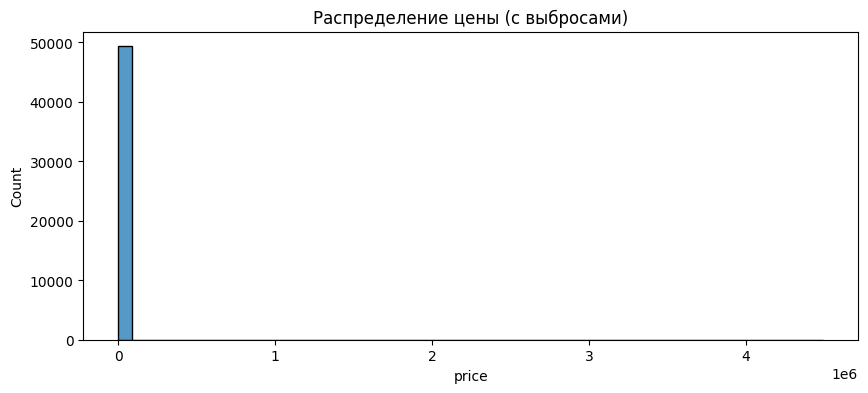

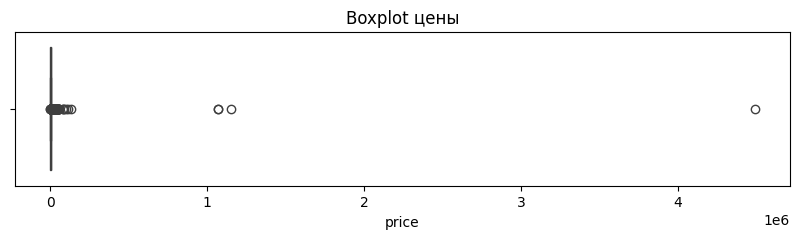

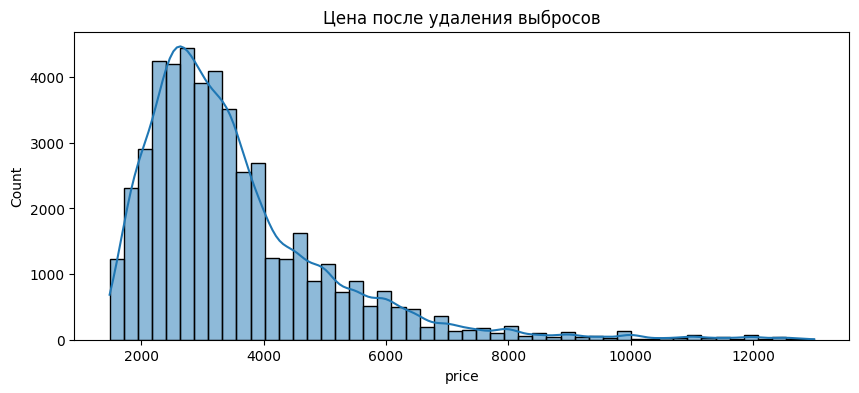

In [39]:
# Гистограмма
plt.figure(figsize=(10, 4))
sns.histplot(df['price'], bins=50)
plt.title('Распределение цены (с выбросами)')
plt.show()

# Boxplot
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['price'])
plt.title('Boxplot цены')
plt.show()

# Удаление выбросов (1 и 99 процентили)
ulimit = np.percentile(df.price.values, 99)
llimit = np.percentile(df.price.values, 1)
df = df[(df['price'] > llimit) & (df['price'] < ulimit)]

# Гистограмма после очистки
plt.figure(figsize=(10, 4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Цена после удаления выбросов')
plt.show()

Тип interest_level: object
interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64


/var/folders/_d/q8_c5ntn1zsdjh_6zk89_ch40000gn/T/ipykernel_99207/296675982.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['interest_level'] = df['interest_level'].map(target_mapping)


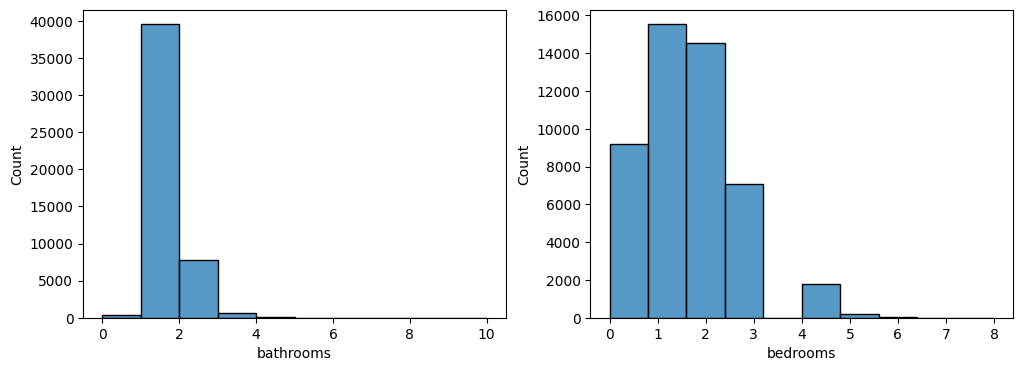

In [40]:
# Тип и значения interest_level
print("Тип interest_level:", df['interest_level'].dtype)
print(df['interest_level'].value_counts())

# Кодирование значений
target_mapping = {'low': 0, 'medium': 1, 'high': 2}
df['interest_level'] = df['interest_level'].map(target_mapping)

# Гистограммы для признаков
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['bathrooms'], ax=axes[0], bins=10)
sns.histplot(df['bedrooms'], ax=axes[1], bins=10)
plt.show()

In [41]:
# Создание квадратичных признаков
df['bathrooms_squared'] = df['bathrooms'] ** 2
df['bedrooms_squared'] = df['bedrooms'] ** 2
df['interest_level_squared'] = df['interest_level'] ** 2

# Матрица с новыми признаками
print(df.corr()['price'])

X = df[['bathrooms', 'bedrooms']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# PolynomialFeatures
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

bathrooms                 0.670808
bedrooms                  0.547310
interest_level           -0.199652
price                     1.000000
bathrooms_squared         0.646949
bedrooms_squared          0.544612
interest_level_squared   -0.182283
Name: price, dtype: float64


/var/folders/_d/q8_c5ntn1zsdjh_6zk89_ch40000gn/T/ipykernel_99207/1749141341.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bathrooms_squared'] = df['bathrooms'] ** 2
/var/folders/_d/q8_c5ntn1zsdjh_6zk89_ch40000gn/T/ipykernel_99207/1749141341.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bedrooms_squared'] = df['bedrooms'] ** 2
/var/folders/_d/q8_c5ntn1zsdjh_6zk89_ch40000gn/T/ipykernel_99207/1749141341.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

In [42]:
## Models Training & Results

In [43]:
# Таблицы результатов
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

def update_results(model_name, train_pred, test_pred):
    global result_MAE, result_RMSE
    
    mae_tr = mean_absolute_error(y_train, train_pred)
    mae_te = mean_absolute_error(y_test, test_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_train, train_pred))
    rmse_te = np.sqrt(mean_squared_error(y_test, test_pred))
    
    new_mae = pd.DataFrame({'model': [model_name], 'train': [mae_tr], 'test': [mae_te]})
    new_rmse = pd.DataFrame({'model': [model_name], 'train': [rmse_tr], 'test': [rmse_te]})
    
    result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
    result_RMSE = pd.concat([result_RMSE, new_rmse], ignore_index=True)

# --- 1. Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
update_results('linear_regression', lr.predict(X_train_poly), lr.predict(X_test_poly))

# --- 2. Decision Tree ---
dt = DecisionTreeRegressor(random_state=21)
dt.fit(X_train_poly, y_train)
update_results('decision_tree', dt.predict(X_train_poly), dt.predict(X_test_poly))

# --- 3. Naive Models ---
# Mean
y_naive_mean_train = np.full_like(y_train, y_train.mean())
y_naive_mean_test = np.full_like(y_test, y_train.mean())
update_results('naive_mean', y_naive_mean_train, y_naive_mean_test)

# Median
y_naive_med_train = np.full_like(y_train, y_train.median())
y_naive_med_test = np.full_like(y_test, y_train.median())
update_results('naive_median', y_naive_med_train, y_naive_med_test)

/var/folders/_d/q8_c5ntn1zsdjh_6zk89_ch40000gn/T/ipykernel_99207/2203971209.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
/var/folders/_d/q8_c5ntn1zsdjh_6zk89_ch40000gn/T/ipykernel_99207/2203971209.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_RMSE = pd.concat([result_RMSE, new_rmse], ignore_index=True)


In [44]:
print("Таблица MAE:")
print(result_MAE)
print("\nТаблица RMSE:")
print(result_RMSE)

Таблица MAE:
               model        train          test
0  linear_regression   752.631597  6.906904e+06
1      decision_tree   752.631597  7.577845e+02
2         naive_mean  1138.341289  1.123574e+03
3       naive_median  1085.933470  1.067371e+03

Таблица RMSE:
               model        train          test
0  linear_regression  1067.498189  6.790888e+08
1      decision_tree  1067.498189  1.086150e+03
2         naive_mean  1588.709729  1.573169e+03
3       naive_median  1635.677354  1.615794e+03


### Итоговый вывод:
На трейне линейка и дерево решений показали одинаковые метрики. А на тесте (degree=10) линейная регрессия "поплыла" из-за переобучения. Соответсвенно дерево - лучшее